نتایج شبیه‌سازی با موفقیت تولید شدند!

خلاصه نتایج:
تعداد کل گام‌های زمانی: 50
تعداد کل دستگاه‌ها: 50
تعداد رله‌های اولیه: 5
بازه Wi-Fi: 200 متر
آستانه سرعت: 15 m/s
آستانه باتری: 75.0%

آمار نهایی:
میانگین کارایی انرژی: 0.3005
میانگین نرخ کل: 1762.30 Mbps
میانگین توان مصرفی: 5857.92 mW

نمونه‌ای از داده‌ها (5 ردیف اول):
   time   total_rate  total_power_mw  num_ue  num_d2d  num_relays  \
0     0  2055.236146     6194.314778      38       12           0   
1     1  1959.232839     6094.788546      39       11           0   
2     2  1957.015545     6094.788546      39       11           0   
3     3  1955.265294     6094.788546      39       11           0   
4     4  1954.150996     6094.788546      39       11           0   

   energy_efficiency  
0           0.331794  
1           0.321460  
2           0.321097  
3           0.320809  
4           0.320627  

وضعیت دستگاه‌ها در آخرین گام زمانی:
  - تعداد UE مستقیم: 42
  - تعداد D2D Client: 8
  - تعداد رله: 0

نتایج در فایل 'dais_re

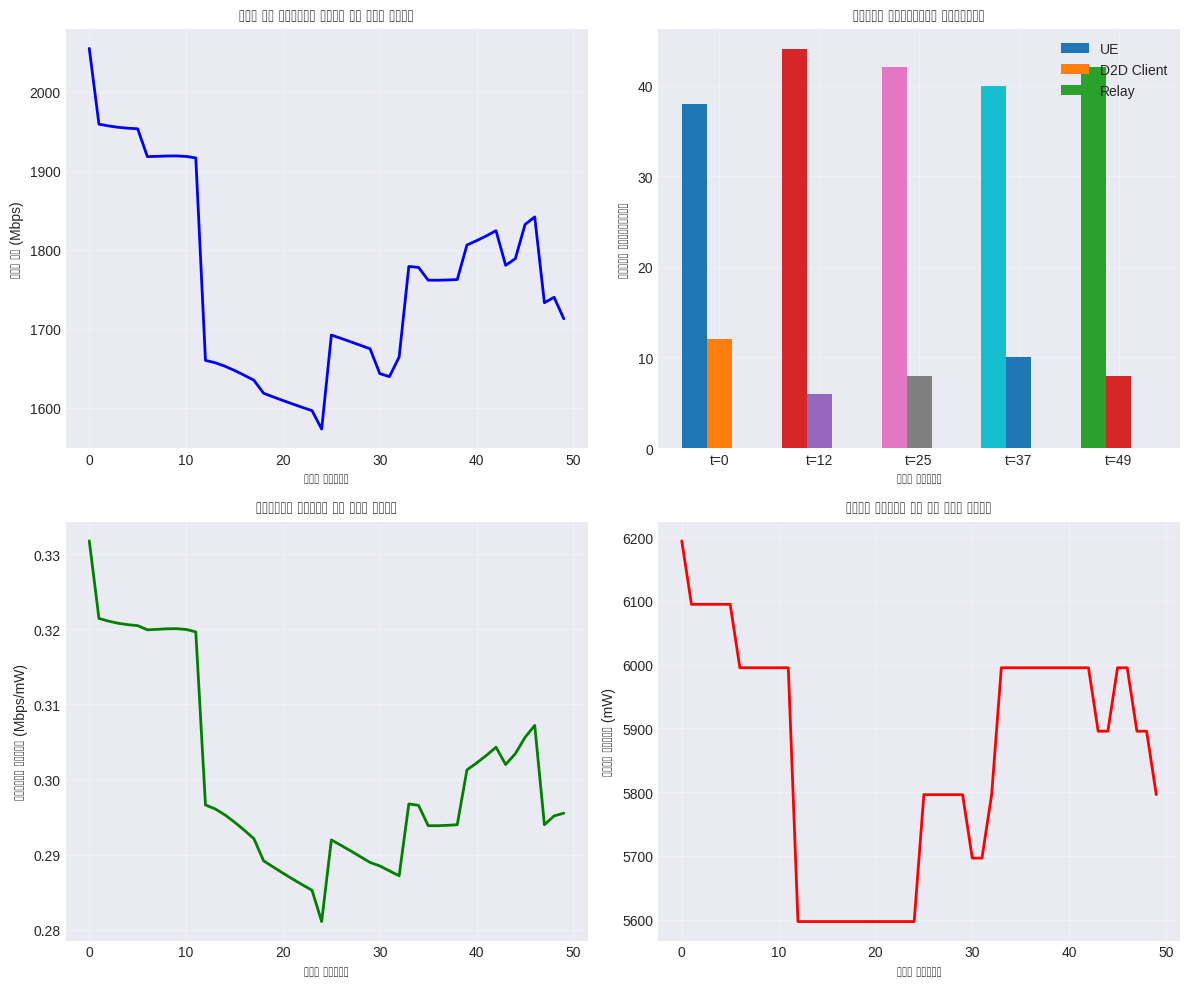


نمودارهای تحلیل در فایل 'dais_simulation_results.png' ذخیره شد.


In [9]:
import math
import random
import pandas as pd
from dataclasses import dataclass, field
import numpy as np

# ===================== پارامترهای شبیه سازی =====================
NUM_DEVICES = 50
TIMESTEPS = 50
AREA_SIZE = 1000

BS_X = AREA_SIZE / 2
BS_Y = AREA_SIZE / 2

WIFI_RANGE = 200
LTE_RANGE = 600

BANDWIDTH_MHZ = 10
NOISE_FIGURE_DB = 9
NOISE_POWER_DBM = -174 + 10 * math.log10(BANDWIDTH_MHZ * 1e6) + NOISE_FIGURE_DB

TX_POWER_UE = 20
TX_POWER_RELAY = 23

PL0_DB = 40
PATHLOSS_EXP = 2.7

BATTERY_THRESHOLD = 0.75
SPEED_THRESHOLD = 15
PERC_RATE = 0.20

# ===================== توابع کمکی =====================
def dbm_to_mw(dbm):
    return 10 ** (dbm / 10)

def path_loss(distance):
    if distance < 1:
        distance = 1
    return PL0_DB + 10 * PATHLOSS_EXP * math.log10(distance)

def snr(tx_dbm, distance):
    rx_dbm = tx_dbm - path_loss(distance)
    return dbm_to_mw(rx_dbm) / dbm_to_mw(NOISE_POWER_DBM)

def shannon_rate(distance, tx_dbm):
    return BANDWIDTH_MHZ * math.log2(1 + snr(tx_dbm, distance))

# ===================== کلاس دستگاه =====================
@dataclass
class Device:
    id: int
    x: float
    y: float
    speed: float
    direction: float
    battery: float
    mode: str = "UE"
    clients: list = field(default_factory=list)

    def move(self):
        self.x = (self.x + math.cos(self.direction) * self.speed) % AREA_SIZE
        self.y = (self.y + math.sin(self.direction) * self.speed) % AREA_SIZE

    def distance_to(self, other_x, other_y):
        return math.hypot(self.x - other_x, self.y - other_y)

# ===================== مقداردهی اولیه =====================
random.seed(1)
np.random.seed(1)

devices = []

for i in range(NUM_DEVICES):
    devices.append(Device(
        id=i,
        x=random.uniform(0, AREA_SIZE),
        y=random.uniform(0, AREA_SIZE),
        speed=random.uniform(0, 5),
        direction=random.uniform(0, 2 * math.pi),
        battery=random.uniform(0.6, 1.0)
    ))

# انتخاب چند رله اولیه
relays = random.sample(devices, k=max(1, NUM_DEVICES // 10))
for r in relays:
    r.mode = "D2DSHR"

# ===================== حلقه اصلی شبیه سازی =====================
results = []

for t in range(TIMESTEPS):
    # حرکت همه دستگاه‌ها
    for d in devices:
        d.move()
        d.clients.clear()  # پاک کردن مشتری‌های مرحله قبل

    total_rate = 0
    total_power = 0

    for d in devices:
        dist_bs = d.distance_to(BS_X, BS_Y)
        rate_bs = shannon_rate(dist_bs, TX_POWER_UE)

        best_rate = rate_bs
        best_mode = "UE"

        # جستجوی بهترین رله برای اتصال D2D
        for r in relays:
            if r.id == d.id:
                continue

            dist = d.distance_to(r.x, r.y)

            if dist <= WIFI_RANGE:
                rate_d2d = shannon_rate(dist, TX_POWER_RELAY)

                # بررسی شرایط برای اتصال D2D
                if rate_d2d > best_rate * (1 + PERC_RATE):
                    if d.speed < SPEED_THRESHOLD and d.battery > BATTERY_THRESHOLD:
                        best_rate = rate_d2d
                        best_mode = "D2DC"
                        # رله را به لیست مشتری‌های رله اضافه می‌کنیم
                        if d.id not in r.clients:
                            r.clients.append(d.id)

        d.mode = best_mode
        total_rate += best_rate

        if best_mode == "UE":
            total_power += dbm_to_mw(TX_POWER_UE)
        else:
            total_power += dbm_to_mw(TX_POWER_RELAY)

    # آمارگیری از وضعیت دستگاه‌ها
    num_ue = sum(1 for d in devices if d.mode == "UE")
    num_d2d = sum(1 for d in devices if d.mode == "D2DC")
    num_relays = sum(1 for d in devices if d.mode == "D2DSHR")

    results.append({
        "time": t,
        "total_rate": total_rate,
        "total_power_mw": total_power,
        "num_ue": num_ue,
        "num_d2d": num_d2d,
        "num_relays": num_relays,
        "energy_efficiency": total_rate / total_power if total_power > 0 else 0
    })

# ===================== ذخیره نتایج =====================
df = pd.DataFrame(results)

# نمایش نتایج
print("=" * 60)
print("نتایج شبیه‌سازی با موفقیت تولید شدند!")
print("=" * 60)
print("\nخلاصه نتایج:")
print(f"تعداد کل گام‌های زمانی: {TIMESTEPS}")
print(f"تعداد کل دستگاه‌ها: {NUM_DEVICES}")
print(f"تعداد رله‌های اولیه: {len(relays)}")
print(f"بازه Wi-Fi: {WIFI_RANGE} متر")
print(f"آستانه سرعت: {SPEED_THRESHOLD} m/s")
print(f"آستانه باتری: {BATTERY_THRESHOLD*100}%")

print("\nآمار نهایی:")
print(f"میانگین کارایی انرژی: {df['energy_efficiency'].mean():.4f}")
print(f"میانگین نرخ کل: {df['total_rate'].mean():.2f} Mbps")
print(f"میانگین توان مصرفی: {df['total_power_mw'].mean():.2f} mW")

print("\nنمونه‌ای از داده‌ها (5 ردیف اول):")
print(df.head())

print("\nوضعیت دستگاه‌ها در آخرین گام زمانی:")
last_result = results[-1]
print(f"  - تعداد UE مستقیم: {last_result['num_ue']}")
print(f"  - تعداد D2D Client: {last_result['num_d2d']}")
print(f"  - تعداد رله: {last_result['num_relays']}")

# ذخیره در فایل CSV
df.to_csv("dais_results.csv", index=False)
print("\nنتایج در فایل 'dais_results.csv' ذخیره شد.")

# ایجاد نمودارهای ساده
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# نمودار 1: نرخ کل در طول زمان
axes[0, 0].plot(df['time'], df['total_rate'], 'b-', linewidth=2)
axes[0, 0].set_title('نرخ کل انتقال داده در طول زمان')
axes[0, 0].set_xlabel('گام زمانی')
axes[0, 0].set_ylabel('نرخ کل (Mbps)')
axes[0, 0].grid(True, alpha=0.3)

# نمودار 2: توزیع حالت‌های ارتباطی
time_points = [0, TIMESTEPS//4, TIMESTEPS//2, 3*TIMESTEPS//4, TIMESTEPS-1]
width = 0.25
for i, tp in enumerate(time_points):
    axes[0, 1].bar(i - width, df.loc[tp, 'num_ue'], width, label='UE' if i==0 else "")
    axes[0, 1].bar(i, df.loc[tp, 'num_d2d'], width, label='D2D Client' if i==0 else "")
    axes[0, 1].bar(i + width, df.loc[tp, 'num_relays'], width, label='Relay' if i==0 else "")
axes[0, 1].set_title('توزیع حالت‌های ارتباطی')
axes[0, 1].set_xlabel('گام زمانی')
axes[0, 1].set_ylabel('تعداد دستگاه‌ها')
axes[0, 1].set_xticks(range(len(time_points)))
axes[0, 1].set_xticklabels([f't={t}' for t in time_points])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# نمودار 3: کارایی انرژی
axes[1, 0].plot(df['time'], df['energy_efficiency'], 'g-', linewidth=2)
axes[1, 0].set_title('کارایی انرژی در طول زمان')
axes[1, 0].set_xlabel('گام زمانی')
axes[1, 0].set_ylabel('کارایی انرژی (Mbps/mW)')
axes[1, 0].grid(True, alpha=0.3)

# نمودار 4: توان مصرفی
axes[1, 1].plot(df['time'], df['total_power_mw'], 'r-', linewidth=2)
axes[1, 1].set_title('توان مصرفی کل در طول زمان')
axes[1, 1].set_xlabel('گام زمانی')
axes[1, 1].set_ylabel('توان مصرفی (mW)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dais_simulation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nنمودارهای تحلیل در فایل 'dais_simulation_results.png' ذخیره شد.")